<a href="https://colab.research.google.com/github/a2w3r4/Basic-Neural-Network-using-Pytorch/blob/main/Convolutional_Neural_Netwoork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

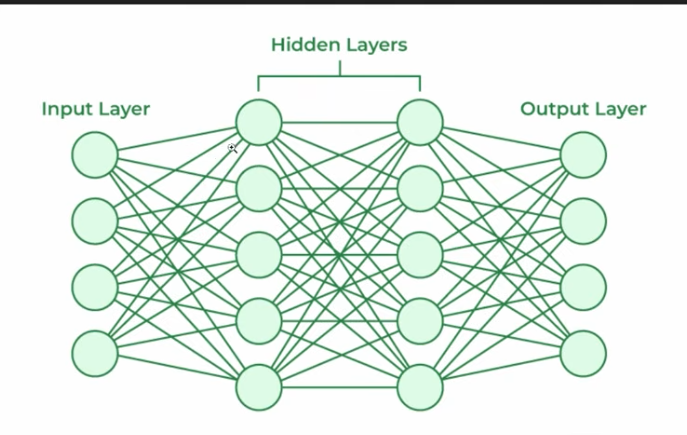

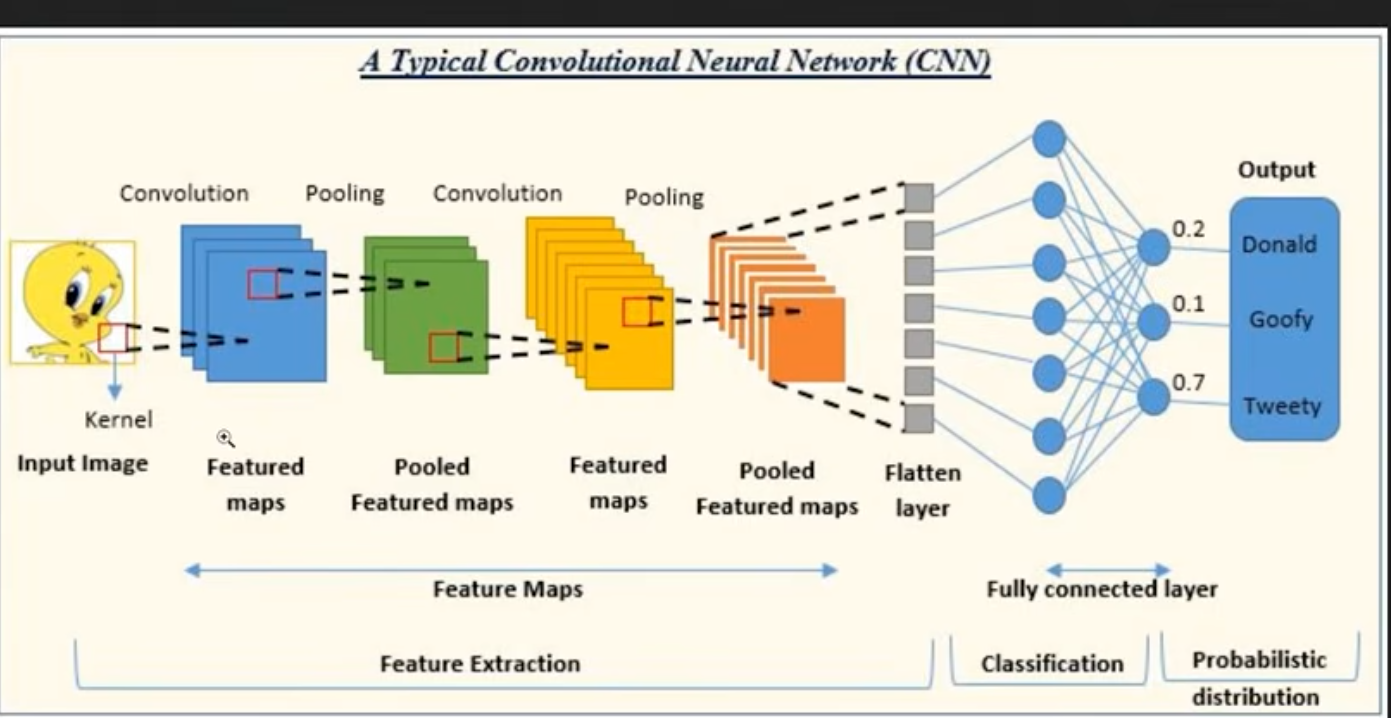

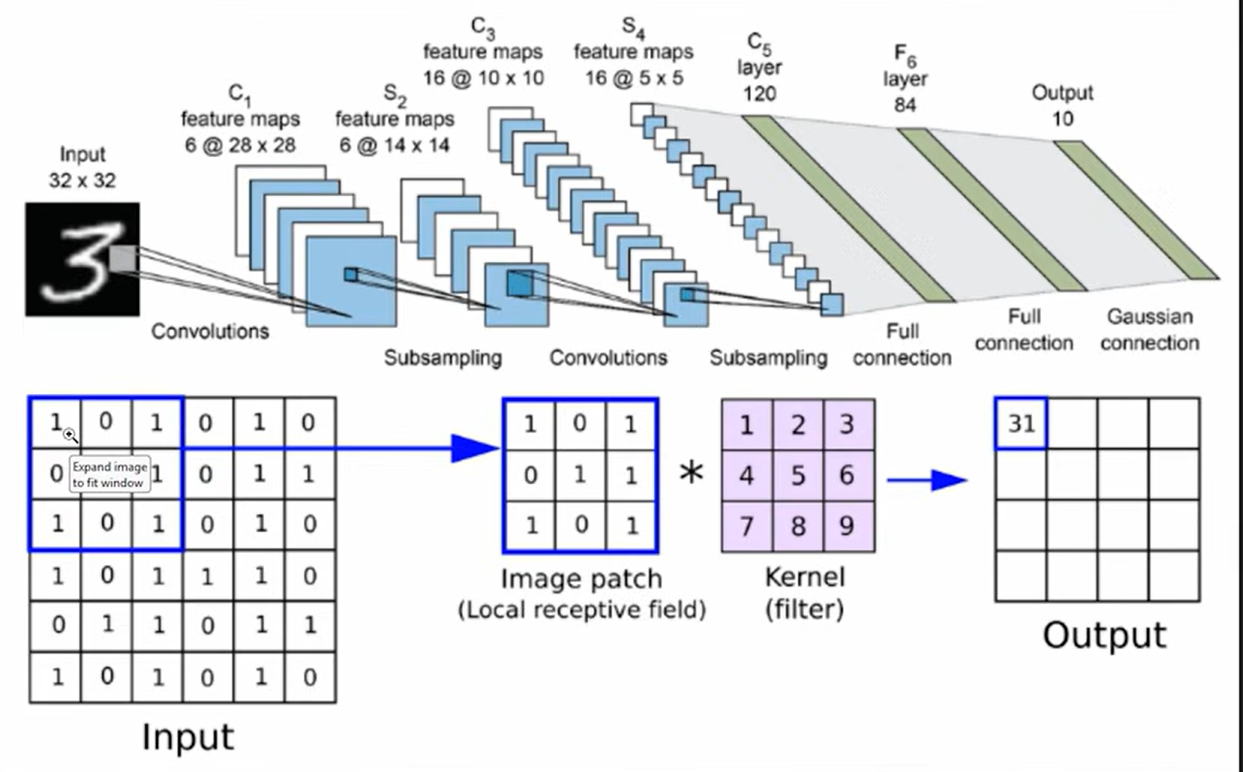

Image is just a matrix with 1's & 0's from 0 to 256 pixel values .

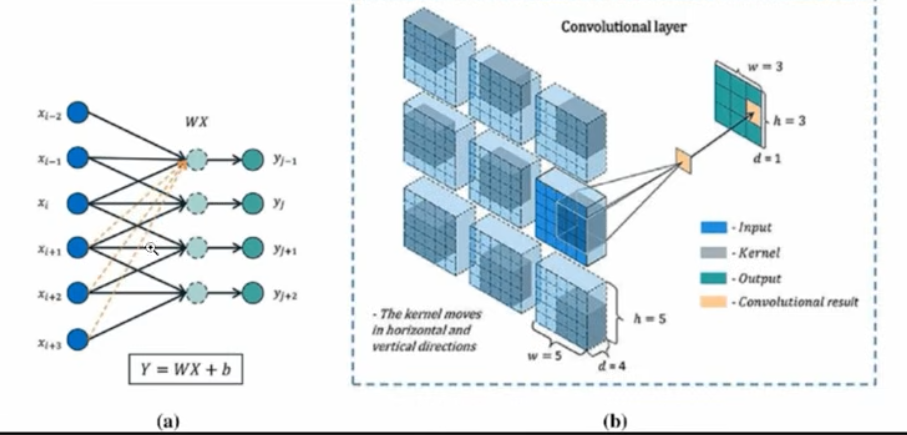

Filtering of Image Pixel (above)

Colour Image Pixel (3D Tensor)

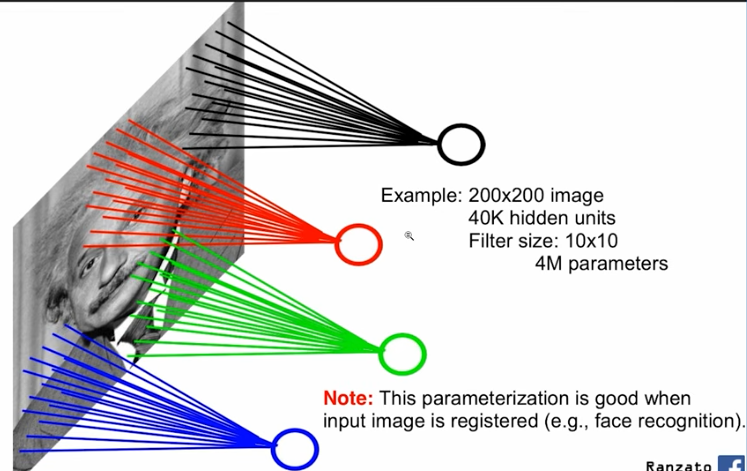

Pooling Layer

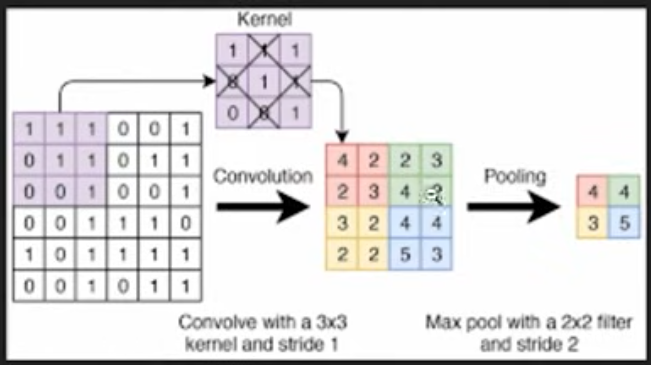

Max Pooling : Taking the max value

Average Pooling : Taking the average value

# CNN

In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

Convert MNIST Image file into Tensor of 4-dimensional (# if images, height, width, color-channel)

In [80]:
transform = transforms.ToTensor()

In [81]:
# Train Data

train_data = datasets.MNIST(root='/cnn.data', train=True, download=True, transform=transform)

In [82]:
# Test Data

test_data = datasets.MNIST(root='/cnn.data', train=False, download=True, transform=transform)

In [83]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn.data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [84]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn.data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [85]:
pwd

'/bin.usr-is-merged'

In [86]:
ls

In [87]:
cd ../

/


In [88]:
pwd

'/'

In [89]:
ls

bin@                dev/     lib.usr-is-merged/  python-apt.tar.xz*   sys/
bin.usr-is-merged/  etc/     media/              root/                tmp/
boot/               home/    mnt/                run/                 tools/
cnn.data/           kaggle/  opt/                sbin@                usr/
content/            lib@     proc/               sbin.usr-is-merged/  var/
datalab/            lib64@   python-apt/         srv/


tmp is our cnn data address

In [90]:
cd cnn_data

[Errno 2] No such file or directory: 'cnn_data'
/


In [91]:
ls

bin@                dev/     lib.usr-is-merged/  python-apt.tar.xz*   sys/
bin.usr-is-merged/  etc/     media/              root/                tmp/
boot/               home/    mnt/                run/                 tools/
cnn.data/           kaggle/  opt/                sbin@                usr/
content/            lib@     proc/               sbin.usr-is-merged/  var/
datalab/            lib64@   python-apt/         srv/


In [92]:
cd ../

/


In [93]:
ls

bin@                dev/     lib.usr-is-merged/  python-apt.tar.xz*   sys/
bin.usr-is-merged/  etc/     media/              root/                tmp/
boot/               home/    mnt/                run/                 tools/
cnn.data/           kaggle/  opt/                sbin@                usr/
content/            lib@     proc/               sbin.usr-is-merged/  var/
datalab/            lib64@   python-apt/         srv/


In [94]:
cd bin.usr-is-merged/

/bin.usr-is-merged


In [95]:
pwd

'/bin.usr-is-merged'

In [96]:
# Start

In [97]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn.data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [98]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn.data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [99]:
# Create a small batch size for images...let's say 10
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)


In [100]:
# Define our CNN Model
# Describe connvolution layer and what it's doing

conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [101]:
# Grab 1 MNIST record/image
for i, (X_Train, y_train) in enumerate(train_data):
  break

In [102]:
X_Train

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [103]:
X_Train.shape

torch.Size([1, 28, 28])

In [104]:
x = X_Train.view(1, 1, 28, 28)

In [105]:
# Perform our first convolution
x = F.relu(conv1(x)) # Rectified Linear Unit for our activation function


In [106]:
x

tensor([[[[0.2143, 0.2143, 0.2143,  ..., 0.2143, 0.2143, 0.2143],
          [0.2143, 0.2143, 0.2143,  ..., 0.2143, 0.2143, 0.2143],
          [0.2143, 0.2143, 0.2143,  ..., 0.2143, 0.2143, 0.2143],
          ...,
          [0.2143, 0.2143, 0.0330,  ..., 0.2143, 0.2143, 0.2143],
          [0.2143, 0.2143, 0.1570,  ..., 0.2143, 0.2143, 0.2143],
          [0.2143, 0.2143, 0.2143,  ..., 0.2143, 0.2143, 0.2143]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.1952,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.1694,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.2049, 0.2049, 0.2049,  ..., 0.2049, 0.2049, 0.2049],
          [0.2049, 0.2049, 0.2049,  ..., 0.2049, 0.2049, 0.2049],
          [0.2049, 0.2049, 0.2049,  ..., 0

In [107]:
# 1 single image, 6 is the filter we asked for, 26*26
x.shape

torch.Size([1, 6, 26, 26])

In [108]:
# pass through the pooling layer
x = F.max_pool2d(x,2,2) # Kernal of 2 and stride of 2



In [109]:
x.shape

torch.Size([1, 6, 13, 13])

In [110]:
# Do  our second convolutional layer
x = F.relu(conv2(x))

In [111]:
x.shape    # Again, we didn't set padding so we lose 2 pixels aroound the outside of the image

torch.Size([1, 16, 11, 11])

In [112]:
# Pooling Layer
x = F.max_pool2d(x, 2, 2)

In [113]:
# 11 / 2 = 5.5 but we've to round down, because you can't invent data to round up

torch.Size([1,16,5,5])

torch.Size([1, 16, 5, 5])

In [114]:
((28-2) / 2-2) / 2

5.5

# Model Class

In [125]:
class COnvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)

    # Fully Connected Layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X, 2, 2)   # 2*2 kernel and stride 2
    # Second Pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X, 2, 2)     # 2*2 kernel and stride 2

    # Re-View to flatten it out
    X = X.view(-1, 16*5*5)  # negative one so that we can vary the batch size

    # Fully Connected Layers
    X  = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)

    return F.log_softmax(X, dim=1)

In [126]:
# Create an Instance of our Model
torch.manual_seed(41)
model = COnvolutionalNetwork()
model

COnvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [150]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Smaller the Learning Rate

Train and Test CNN Model

In [151]:
import time
start_time = time.time()

# Create Variables to Track Things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For Loop of Epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  # Train
  for b, (X_train, y_train) in enumerate(train_loader):
    b += 1      # Start our batches at 1
    y_pred = model(X_train) # get predicted values from the training set
    loss = criterion(y_pred, y_train) # Calculate the loss

    predicted = torch.max(y_pred.data, 1)[1]   # add up to the no of correct predictions
    batch_corr = (predicted == y_train).sum()   # How many we got correct from this batch
    trn_corr += batch_corr.item()          # Keep track as we go along in training

    # Update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print out results
    if b % 600 == 0:
      print(f'Epoch: {i}   Batch: {b}   Loss: {loss.item()}')

  train_losses.append(loss.item())
  train_correct.append(trn_corr)

  # Test
  with torch.no_grad():  # No gradient so we don't update our weights and biases with test
    for b, (X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1]   # Adding up correct predictions
      tst_corr += (predicted == y_test).sum().item()     # T = 1   F = 0 and sum away

  loss = criterion(y_val, y_test)
  test_losses.append(loss.item())
  test_correct.append(tst_corr)

current_time = time.time()
total = current_time - start_time
print(f'Training Took: {total/60:.2f} minutes!')

Epoch: 0   Batch: 600   Loss: 0.729667067527771
Epoch: 0   Batch: 1200   Loss: 0.2224837988615036
Epoch: 0   Batch: 1800   Loss: 0.21300117671489716
Epoch: 0   Batch: 2400   Loss: 0.0022961292415857315
Epoch: 0   Batch: 3000   Loss: 0.010573478415608406
Epoch: 0   Batch: 3600   Loss: 0.08786877989768982
Epoch: 0   Batch: 4200   Loss: 0.08242467790842056
Epoch: 0   Batch: 4800   Loss: 0.008157262578606606
Epoch: 0   Batch: 5400   Loss: 0.43319424986839294
Epoch: 0   Batch: 6000   Loss: 0.3654846251010895
Epoch: 1   Batch: 600   Loss: 0.16536909341812134
Epoch: 1   Batch: 1200   Loss: 0.10856137424707413
Epoch: 1   Batch: 1800   Loss: 0.17312827706336975
Epoch: 1   Batch: 2400   Loss: 0.010032381862401962
Epoch: 1   Batch: 3000   Loss: 0.057618774473667145
Epoch: 1   Batch: 3600   Loss: 0.008387927897274494
Epoch: 1   Batch: 4200   Loss: 0.000493318191729486
Epoch: 1   Batch: 4800   Loss: 0.004559011198580265
Epoch: 1   Batch: 5400   Loss: 0.04548104479908943
Epoch: 1   Batch: 6000   Los

In [128]:
# Graph the loss at epoch

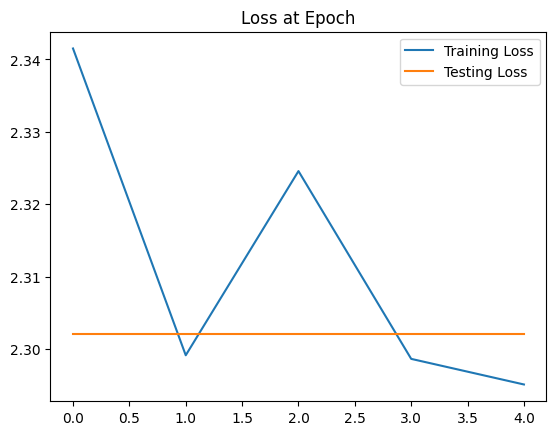

In [131]:
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Testing Loss')
plt.title('Loss at Epoch')
plt.legend()

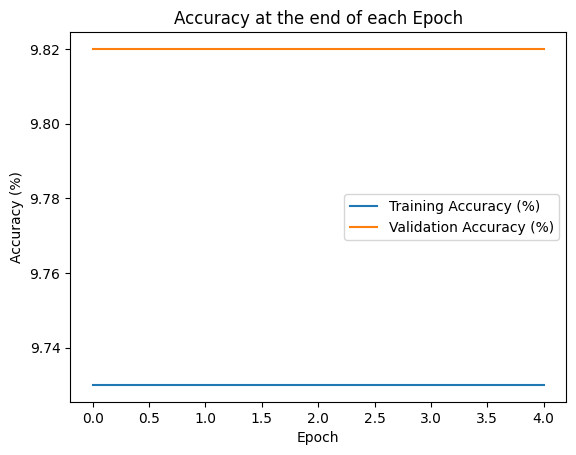

In [148]:
plt.plot([i/60000 * 100 for i in train_correct], label='Training Accuracy (%)')
plt.plot([i/10000 * 100 for i in test_correct], label='Validation Accuracy (%)')
plt.title('Accuracy at the end of each Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

In [149]:
test_loading_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

with torch.no_grad():
  correct = 0
  for X_test, y_test in test_loading_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val.data, 1)[1]
    correct += (predicted == y_test).sum()


In [145]:
#  Did for Correct

correct.item()

982

In [146]:
correct.item()/len(test_data)

0.0982

In [143]:
correct.item()/len(test_data)*100

9.82